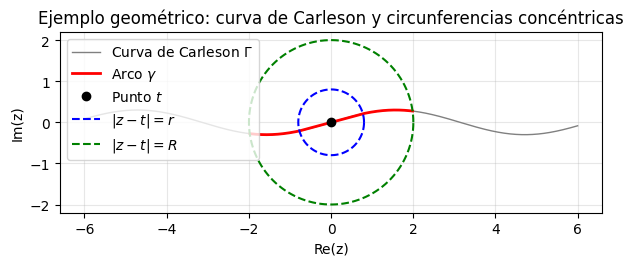

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Definimos una curva de Carleson (Lipschitz)
# -----------------------------
x = np.linspace(-6, 6, 2000)
y = 0.3 * np.sin(x)          # función Lipschitz
gamma = x + 1j * y           # curva compleja

# -----------------------------
# 2. Punto t sobre la curva
# -----------------------------
t_index = 1000               # índice central
t = gamma[t_index]

# -----------------------------
# 3. Radios de las circunferencias concéntricas
# -----------------------------
r = 0.8
R = 2.0

theta = np.linspace(0, 2*np.pi, 400)
circle_r = t + r * np.exp(1j * theta)
circle_R = t + R * np.exp(1j * theta)

# -----------------------------
# 4. Seleccionamos un arco de la curva
#    (puntos entre las dos circunferencias)
# -----------------------------
distances = np.abs(gamma - t)
arc_mask = (distances >= r) & (distances <= R)
arc = gamma[arc_mask]

# -----------------------------
# 5. Gráfica
# -----------------------------
plt.figure(figsize=(7, 7))

# Curva completa
plt.plot(gamma.real, gamma.imag, color="gray", lw=1, label="Curva de Carleson $\\Gamma$")

# Arco seleccionado
plt.plot(arc.real, arc.imag, color="red", lw=2, label="Arco $\\gamma$")

# Punto t
plt.plot(t.real, t.imag, "ko", label="Punto $t$")

# Circunferencias
plt.plot(circle_r.real, circle_r.imag, "b--", label=f"$|z-t| = r$")
plt.plot(circle_R.real, circle_R.imag, "g--", label=f"$|z-t| = R$")

plt.gca().set_aspect("equal")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.title("Ejemplo geométrico: curva de Carleson y circunferencias concéntricas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


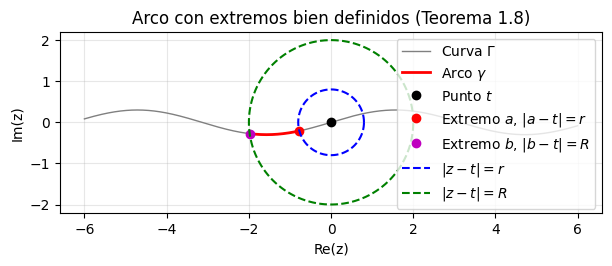

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Curva de Carleson (Lipschitz)
x = np.linspace(-6, 6, 4000)
y = 0.3 * np.sin(x)
Gamma = x + 1j * y

# Punto t en la curva
t_index = 2000
t = Gamma[t_index]

# Radios
r = 0.8
R = 2.0

# Distancias radiales
dist = np.abs(Gamma - t)

# Índices de intersección con |z-t| = r y |z-t| = R
idx_r = np.argmin(np.abs(dist - r))
idx_R = np.argmin(np.abs(dist - R))

# Aseguramos el orden correcto
i_start = min(idx_r, idx_R)
i_end   = max(idx_r, idx_R)

# Extremos
a = Gamma[idx_r]   # |a - t| ≈ r
b = Gamma[idx_R]   # |b - t| ≈ R

# Arco correcto
gamma = Gamma[i_start:i_end+1]

# Circunferencias
theta = np.linspace(0, 2*np.pi, 400)
circle_r = t + r * np.exp(1j * theta)
circle_R = t + R * np.exp(1j * theta)

# Gráfica
plt.figure(figsize=(7,7))

plt.plot(Gamma.real, Gamma.imag, color="gray", lw=1, label=r"Curva $\Gamma$")
plt.plot(gamma.real, gamma.imag, color="red", lw=2, label=r"Arco $\gamma$")

plt.plot(t.real, t.imag, "ko", label=r"Punto $t$")
plt.plot(a.real, a.imag, "ro", label=r"Extremo $a$, $|a-t|=r$")
plt.plot(b.real, b.imag, "mo", label=r"Extremo $b$, $|b-t|=R$")

plt.plot(circle_r.real, circle_r.imag, "b--", label=r"$|z-t|=r$")
plt.plot(circle_R.real, circle_R.imag, "g--", label=r"$|z-t|=R$")

plt.gca().set_aspect("equal")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Arco con extremos bien definidos (Teorema 1.8)")

plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Curva de Carleson (Lipschitz)
# -----------------------------
x = np.linspace(-6, 6, 4000)
y = 0.3 * np.sin(x)
Gamma = x + 1j * y

# Punto t en la curva
t_index = 2000
t = Gamma[t_index]

# Radios
r = 0.8
R = 2.0

# Distancias a t
dist = np.abs(Gamma - t)

# Intersecciones con |z-t| = r y |z-t| = R
idx_r = np.argmin(np.abs(dist - r))
idx_R = np.argmin(np.abs(dist - R))

i_start = min(idx_r, idx_R)
i_end   = max(idx_r, idx_R)

# Arco γ
gamma = Gamma[i_start:i_end+1]

# -----------------------------
# Cálculo del argumento
# -----------------------------
angles = np.unwrap(np.angle(gamma - t))
delta_arg = np.max(angles) - np.min(angles)

# -----------------------------
# Comparación con la cota
# -----------------------------
ratio = R / r

print("Variación del argumento Δ(γ):", delta_arg)
print("Razón R/r:", ratio)
print("Comparación Δ(γ) vs R/r:", delta_arg / ratio)


Variación del argumento Δ(γ): 0.12655399047367233
Razón R/r: 2.5
Comparación Δ(γ) vs R/r: 0.05062159618946893
